In [33]:
!pip install pandas openpyxl xlrd

In [34]:
import pandas as pd 

In [35]:
data = pd.read_excel("C:/Users/kraus/Downloads/GSAF5 (2).xls")

In [36]:
data.head(3)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,6th June,2026.0,Unprovoked,Australia,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,...,Great White shark 4.5 m,Simon De Marchi: ABC News: 9 News: The Guardian:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1st June,2026.0,Unprovoked,Brazil,Recife,Boa Via gem beach,Swimming,Marcela Vitoria de Lima Santos,F,19,...,Tiger shark 3m,Keith Cowley: Andrew Currie: Kevin McMurray Tr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1st June,2026.0,Unprovoked,Brazil,Jaboatao dos Guarapes,PierrebBeach,Swimming,Joao Lucas Castro Nemezio,M,11,...,Bull shark,Keith Cowley: Andrew Currie: Todd Smith: The U...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
data.shape # 2.366 rows/person

(7097, 23)

In [38]:
df = data[["Country", "Activity", "Location", "Sex", "Fatal Y/N", "Species ", "Type"]].copy()

# created a clean independent copy of the data, not just a view

In [39]:
df.head()

,Country,Activity,Location,Sex,Fatal Y/N,Species,Type
0,Australia,Spearfishing,Michaelmas Island King George Sound,M,Y,Great White shark 4.5 m,Unprovoked
1,Brazil,Swimming,Boa Via gem beach,F,N,Tiger shark 3m,Unprovoked
2,Brazil,Swimming,PierrebBeach,M,N,Bull shark,Unprovoked
3,Australia,Surfing,Red Cliff beach Yuraygir National Park,M,N,Bull shark,Unprovoked
4,USA,Paddling surfboard,Cromwell's beach Oahu,M,N,2.4m (8ft) shark,Unprovoked


In [40]:
df.columns = df.columns.str.strip()

In [41]:
df.columns

Index(['Country', 'Activity', 'Location', 'Sex', 'Fatal Y/N', 'Species',
       'Type'],
      dtype='object')

In [62]:
#Start of Keagan - Species and Fatal Y/N data cleaning

In [42]:
df['Species'].value_counts()

# check how many unique values exist in Species
# and how often each one appears - reveals how messy the data is - "Diagnose the mess"

Species
White shark                                                                                                                      194
Shark involvement prior to death was not confirmed                                                                               105
Invalid                                                                                                                          102
Shark involvement not confirmed                                                                                                   92
Tiger shark                                                                                                                       89
                                                                                                                                ... 
12' to 14' white shark                                                                                                             1
Raggedtooth shark, 2.5m                                      

In [57]:
keywords = ['white', 'bull', 'tiger']

# map messy Species strings to clean labels using keyword matching - confirming that searching for "white, bull, tiger" catches the right sharks

for keyword in keywords:
    species_lower = df['Species'].dropna().str.lower()
    matches = species_lower.str.contains(keyword)
    print(f"\n--- '{keyword}' matches ---")
    print(sorted(df['Species'].dropna()[matches].unique()))


--- 'white' matches ---
[' White shark', " White shark, 7' ", " white shark, 15' ", '"whitetip shark"', "0.9 m to 1.2 m [3' to 4'] white shark", '1 m shark, possibly whitetip reef shark', "1.5 m [5'] white shark or sevengill shark", '1.5 m white-tipped reef shark', "1.8 m [6'] white shark", "1.8 m to 2.4 m [6' to 8'] sharks, most were oceanic whitetip sharks", "1.8 m to 2.4 m [6' to 8'] white shark", "12' to 14' white shark", "12' white shark", "14' to 16' white shark", "14' white shark", "16' white shark", "17' white shark", "18' white shark", "2 m [6.75'] white shark", '2 white shark: 13\' & 9"8"', "2.3 m [7.5'] white shark, identified by M. Smale", "2.4 m [8'] white shark", "2.4 m [8'] white shark, species identity confirmed by tooth fragment", "2.4 m [8'] white shark, species identity confirmed by witnesses & tooth pattern in surfboard", "2.4 m to 3 m [8' to 10'] white shark", "2.5 m [8.25'] white shark", "2.5 m [8.25'] white shark ", "2.5 m to 3 m [8.25' to 10']  white shark", '2

In [61]:
import numpy as np

# map all species variations to clean labels using keyword matching, 
# case=False means upper/lower case doesn't matter, na=False means if the value is empty/NaN just answer false instead of crashing 
# verify the result
# creates a new Species_Clean column rather than overwriting the original

conditions = [
    df['Species'].str.contains('white|pointer', case=False, na=False),
    df['Species'].str.contains('bull', case=False, na=False),
    df['Species'].str.contains('tiger', case=False, na=False),
]
choices = ['Great White', 'Bull Shark', 'Tiger Shark']

df['Species_Clean'] = np.select(conditions, choices, default='Other')

df['Species_Clean'].value_counts()

Species_Clean
Other          5123
Great White     750
Tiger Shark     332
Bull Shark      249
Name: count, dtype: int64

In [43]:
df['Fatal Y/N'].value_counts()

# check for y/n and any other values that needs fixing

Fatal Y/N
N          4950
Y          1494
UNKNOWN      71
 N            7
F             5
M             3
n             1
Nq            1
2017          1
Y x 2         1
N             1
y             1
Name: count, dtype: int64

In [44]:
df['Fatal Y/N'] = df['Fatal Y/N'].str.strip().str.upper()
df = df[df['Fatal Y/N'].isin(['Y', 'N'])]

# clean the Fatal Y/N column: remove any leading/trailing whitespace then make everything uppercase, keep only the rows where the value is exactly Y or N, drop everything else

In [45]:
df['Fatal Y/N'].value_counts()

# confirming only Y and N remain after cleaning

Fatal Y/N
N    4959
Y    1495
Name: count, dtype: int64

In [64]:
# calculate what % of attacks were fatal per species
# to test hypothesis: Are Great White attacks more likely to be fatal?

fatality_rate =  df.groupby('Species_Clean')['Fatal Y/N'].apply(
    lambda x: (x == 'Y').sum() / len(x) * 100
).round(1)

print(fatality_rate)

Species_Clean
Bull Shark     20.5
Great White    24.3
Other          23.1
Tiger Shark    24.4
Name: Fatal Y/N, dtype: float64


In [65]:
# Conclusions: Species alone isn't a strong predictor of fatality - the top 3 named sharks sit within 20 to 24 percent
# Great Whites have a more famous/worst reputation, but Tiger Sharks are marginally more likely to be fatal
# Similarity  across species suggests other factors (location, activity, access to medical) care might matter more than species
# The "Other" category at 23.1% is suspiciously high and contains mixed or unknown species, likely skewing things

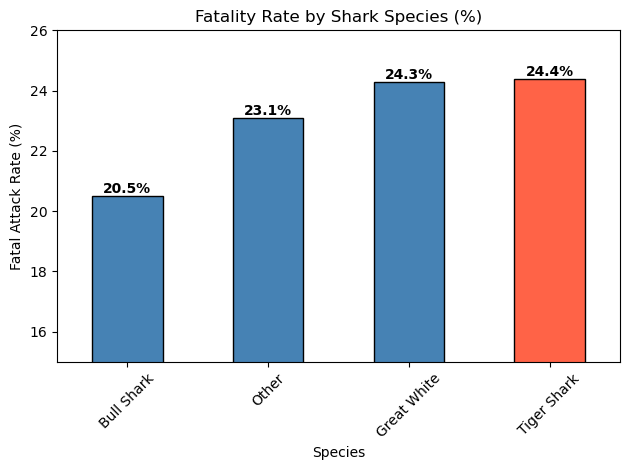

In [70]:
import matplotlib.pyplot as plt

# Bar chart comparing fatality rates across shark species

fatality_rate.sort_values().plot(
    kind='bar',
    color=['steelblue', 'steelblue', 'steelblue', 'tomato'],
    edgecolor='black'
)

plt.title('Fatality Rate by Shark Species (%)')
plt.xlabel('Species')
plt.ylabel('Fatal Attack Rate (%)')
plt.xticks(rotation=45)
plt.ylim(15, 26)

for i, v in enumerate(fatality_rate.sort_values()):
    plt.text(i, v + 0.1, str(v) + '%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Great Whites have the most fearsome reputation, but the data tells a more interesting story
# Tiger Sharks are marginally the most deadly, and all three major species are far closer in fatality rate than popular culture would suggest.
# This raises a bigger question: if species doesn't dramatically predict fatality, what does?